# Ejercicio 2: Similitud entre series con `catch22`

Se aborda el ejercicio 2 del laboratorio, donde cada bloque de este cuaderno está etiquetado con el número de inciso al que corresponde.

**Resumen**

| Inciso | Contenido | Sección |
|---|---|---|
| 2 | Series utilizadas | 2 |
| 2.1 | Idea detrás de catch22 | 2.1 |
| 2.2 | Extracción de las 22 características | 2.2 |
| 2.3 | Matriz series × características | 2.3 |
| 2.4 | Estandarización | 2.4 |
| 2.5 | PCA, clustering, heatmap, correlación, distancias | 2.5.1 – 2.5.5 |
| 2.6 – 2.13 | Análisis e interpretación | 2.6 – 2.13 |
| 2.14 | LSTM con características catch22 vs. mejor LSTM previo | 2.14 |




## 0. Configuración e importación de librerías

In [5]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

import pycatch22 as catch22
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

AZUL, NARANJA, VERDE, ROJO, GRIS, MORADO = "#2563eb", "#f59e0b", "#10b981", "#ef4444", "#94a3b8", "#8b5cf6"
PALETA = [AZUL, NARANJA, VERDE, ROJO, MORADO, "#14b8a6", "#ec4899", GRIS, "#f97316"]

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

DIR_PROC = Path("./data")


## 2. Series utilizadas

Se utilizan todas las series construidas en el laboratorio anterior: la serie
`Total`, las 4 series de la categoría *Tipo de viajero* + la combinada
(`Turista`, `Excursionista`, `Cruceristas`, `Viajero`, `Turista + Excursionista`), y las 3
series de la categoría *País de residencia* (Top-3): `País: Guatemala`,
`País: El Salvador`, `País: Estados Unidos de América`. En total, **9 series**, cada una
con sus 147 observaciones mensuales de entrenamiento (enero 2009 – marzo 2021).

In [6]:
train = pd.read_csv(DIR_PROC / "series_mensuales_train.csv", index_col=0, parse_dates=True)
train.index.freq = pd.tseries.frequencies.to_offset("MS")

print(f"{train.shape[1]} series, {train.shape[0]} meses cada una ({train.index.min().date()} a {train.index.max().date()})")
for c in train.columns:
    print(f"  - {c}")


9 series, 147 meses cada una (2009-01-01 a 2021-03-01)
  - Total
  - Cruceristas
  - Excursionista
  - Turista
  - Viajero
  - Turista + Excursionista
  - País: Guatemala
  - País: El Salvador
  - País: Estados Unidos de América


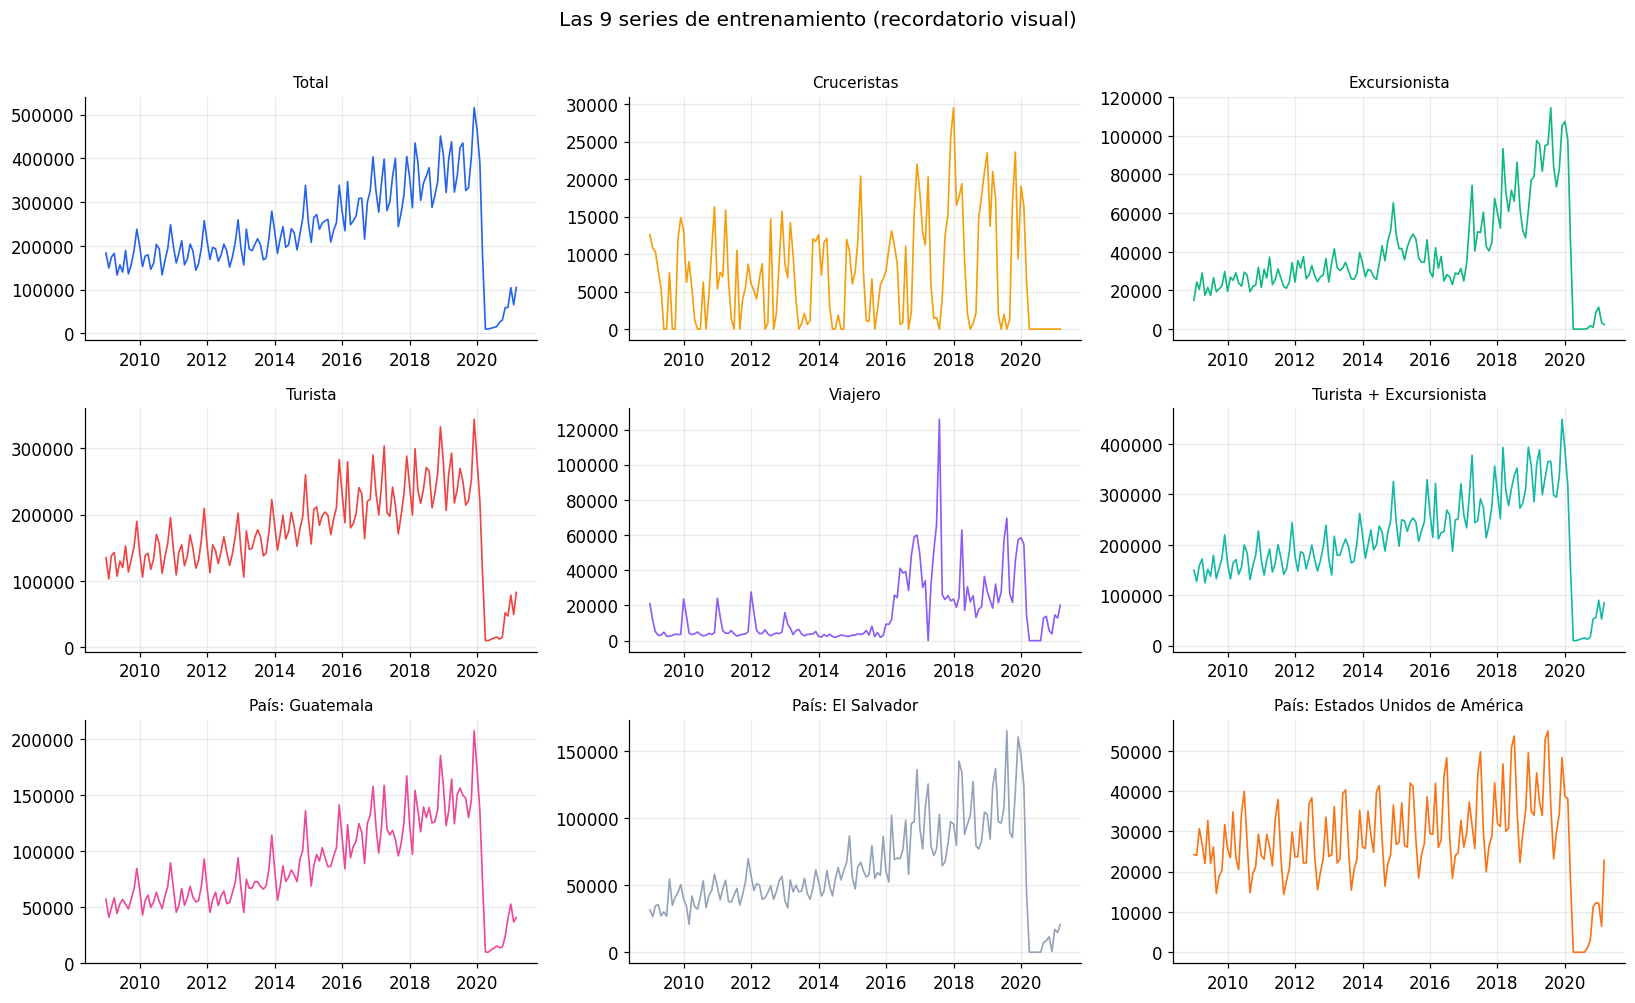

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=False)
for ax, (col, color) in zip(axes.flatten(), zip(train.columns, PALETA)):
    ax.plot(train.index, train[col].values, color=color, linewidth=1.1)
    ax.set_title(col, fontsize=10)
fig.suptitle("Las 9 series de entrenamiento (recordatorio visual)", y=1.01)
plt.tight_layout(); plt.show()


## 2.1. ¿Cuál es la idea detrás de catch22 y por qué es importante?

`catch22` o *22 CAnonical Time-series CHaracteristics* es un conjunto reducido de 22
características seleccionadas, mediante un proceso basado en datos, a partir de un
banco mucho más grande de series de tiempo (la librería
*hctsa*, *highly comparative time-series analysis*). La idea central, presentada por Lubba
et al. (2019), es la siguiente:

- Se evaluó el poder de más de 7,000 características para distinguir y/o clasificar series
  de tiempo en decenas de conjuntos de datos reales muy diversos.
- Mediante un procedimiento de selección,
  se redujo ese banco a solo 22 características que, en conjunto, conservan casi todo el
  poder discriminativo del conjunto completo de 7,000+.
- Cada una de las 22 características resultantes es, además, interpretable, es decir que mide algo
  concreto, como la forma de la distribución, memoria,autocorrelación, periodicidad, predictibilidad, etc. y barata de calcular.

**¿Por qué es importante?** Porque permite resumir cualquier serie de tiempo sin
importar su longitud o escala en un vector numérico fijo de 22 valores que puede
compararse directamente con el de otra serie usando distancias, clustering o PCA, algo que
comparar las series "punto a punto" no permite.

## 2.2. Extracción de las 22 características de catch22

Se calcula el conjunto completo de 22 características de `catch22` para cada una de
las 9 series de entrenamiento.

In [26]:
filas_features = {}
nombres_features = None
for col in train.columns:
    valores = train[col].dropna().astype(float).values.tolist()
    resultado = catch22.catch22_all(valores)
    filas_features[col] = resultado["values"]
    nombres_features = resultado["names"]

print(f"Se calcularon {len(nombres_features)} características para cada una de las {len(filas_features)} series.")
print("\nNombres de las 22 características de catch22:")
for n in nombres_features:
    print(" -", n)


Se calcularon 22 características para cada una de las 9 series.

Nombres de las 22 características de catch22:
 - DN_HistogramMode_5
 - DN_HistogramMode_10
 - CO_f1ecac
 - CO_FirstMin_ac
 - CO_HistogramAMI_even_2_5
 - CO_trev_1_num
 - MD_hrv_classic_pnn40
 - SB_BinaryStats_mean_longstretch1
 - SB_TransitionMatrix_3ac_sumdiagcov
 - PD_PeriodicityWang_th0_01
 - CO_Embed2_Dist_tau_d_expfit_meandiff
 - IN_AutoMutualInfoStats_40_gaussian_fmmi
 - FC_LocalSimple_mean1_tauresrat
 - DN_OutlierInclude_p_001_mdrmd
 - DN_OutlierInclude_n_001_mdrmd
 - SP_Summaries_welch_rect_area_5_1
 - SB_BinaryStats_diff_longstretch0
 - SB_MotifThree_quantile_hh
 - SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1
 - SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
 - SP_Summaries_welch_rect_centroid
 - FC_LocalSimple_mean3_stderr


## 2.3. Matriz series × características

In [9]:
df_features = pd.DataFrame(filas_features, index=nombres_features).T
df_features.index.name = "Serie"

print(f"Matriz de características: {df_features.shape[0]} filas (series) x {df_features.shape[1]} columnas (características de catch22)")
df_features.round(3)


Matriz de características: 9 filas (series) x 22 columnas (características de catch22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total,-0.741,-0.493,8.322,10.0,0.457,-0.108,0.932,42.0,0.062,11.0,...,0.033,0.619,0.891,0.823,6.0,1.780,0.850,0.775,0.147,0.616
Cruceristas,-0.627,-0.840,1.727,6.0,0.111,-0.082,0.870,9.0,0.004,11.0,...,0.250,0.483,0.082,0.680,5.0,2.043,0.175,0.775,0.540,0.983
Excursionista,-0.174,-0.412,7.710,14.0,0.467,-0.100,0.890,38.0,0.023,43.0,...,0.071,0.707,0.884,0.848,4.0,1.870,0.825,0.850,0.147,0.574
Turista,0.019,-0.231,8.163,10.0,0.331,-0.056,0.966,30.0,0.046,11.0,...,0.045,0.524,0.891,0.795,6.0,1.881,0.150,0.775,0.147,0.647
Viajero,-0.159,-0.491,8.768,4.0,0.157,-0.885,0.753,18.0,0.062,4.0,...,0.029,0.422,-0.293,0.653,5.0,1.836,0.850,0.700,0.196,0.809
Turista + Excursionista,0.175,-0.581,8.106,10.0,0.467,-0.068,0.918,30.0,0.046,11.0,...,0.045,0.626,0.891,0.817,6.0,1.833,0.850,0.750,0.147,0.614
País: Guatemala,-0.449,-0.696,8.935,10.0,0.393,-0.019,0.938,49.0,0.111,11.0,...,0.026,0.633,0.857,0.837,6.0,1.722,0.850,0.775,0.098,0.594
País: El Salvador,-0.354,-0.599,8.383,3.0,0.456,-0.129,0.911,42.0,0.062,3.0,...,0.033,0.633,0.884,0.790,5.0,1.770,0.850,0.825,0.147,0.655
País: Estados Unidos de América,-0.042,-0.290,1.767,2.0,0.178,-0.079,0.918,12.0,0.026,3.0,...,0.100,0.469,0.884,0.581,5.0,2.123,0.150,0.700,0.368,0.928


## 2.4. Estandarización de las características

Las 22 características de `catch22` tienen escalas muy distintas entre sí. Antes de cualquier análisis comparativo (PCA, clustering,
distancias) se estandarizan con z-score (media 0, desviación estándar 1) por
característica, para que ninguna domine por su escala.

In [10]:
escalador = StandardScaler()
X = escalador.fit_transform(df_features.values)
X_df = pd.DataFrame(X, index=df_features.index, columns=df_features.columns)

print("Verificación: media y desviación estándar por característica tras estandarizar (deben ser ~0 y ~1):")
print(pd.DataFrame({"media": X_df.mean().round(6), "std": X_df.std(ddof=0).round(6)}).T)


Verificación: media y desviación estándar por característica tras estandarizar (deben ser ~0 y ~1):
       DN_HistogramMode_5  DN_HistogramMode_10  CO_f1ecac  CO_FirstMin_ac  \
media                -0.0                 -0.0       -0.0            -0.0   
std                   1.0                  1.0        1.0             1.0   

       CO_HistogramAMI_even_2_5  CO_trev_1_num  MD_hrv_classic_pnn40  \
media                      -0.0           -0.0                   0.0   
std                         1.0            1.0                   1.0   

       SB_BinaryStats_mean_longstretch1  SB_TransitionMatrix_3ac_sumdiagcov  \
media                              -0.0                                 0.0   
std                                 1.0                                 1.0   

       PD_PeriodicityWang_th0_01  ...  FC_LocalSimple_mean1_tauresrat  \
media                        0.0  ...                             0.0   
std                          1.0  ...                             1

## 2.5. Análisis sobre la matriz estandarizada

### 2.5.1. Análisis de Componentes Principales (PCA)

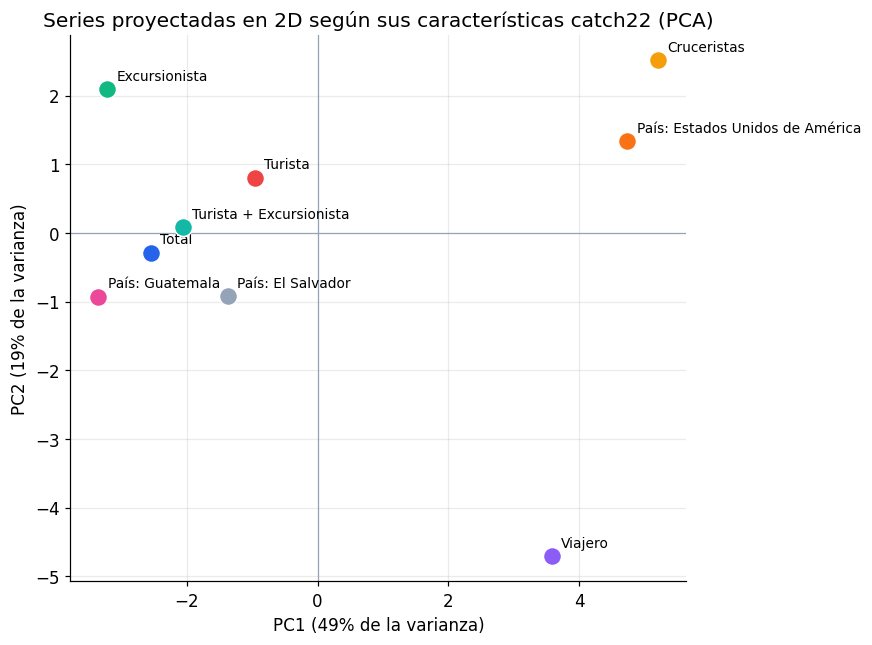

Varianza explicada: PC1=49.3%  PC2=18.8%  Total=68.1%


In [11]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
var_explicada = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
for i, nombre in enumerate(df_features.index):
    ax.scatter(coords[i, 0], coords[i, 1], s=140, color=PALETA[i % len(PALETA)], edgecolor="white", zorder=3)
    ax.annotate(nombre, (coords[i, 0], coords[i, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.axhline(0, color=GRIS, linewidth=0.8); ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel(f"PC1 ({var_explicada[0]*100:.0f}% de la varianza)")
ax.set_ylabel(f"PC2 ({var_explicada[1]*100:.0f}% de la varianza)")
ax.set_title("Series proyectadas en 2D según sus características catch22 (PCA)")
plt.tight_layout(); plt.show()

print(f"Varianza explicada: PC1={var_explicada[0]*100:.1f}%  PC2={var_explicada[1]*100:.1f}%  Total={sum(var_explicada)*100:.1f}%")


In [12]:
cargas = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=["PC1", "PC2"])
print("Características con mayor peso (carga) en PC1:")
print(cargas.reindex(cargas["PC1"].abs().sort_values(ascending=False).index).head(6))
print("\\nCaracterísticas con mayor peso (carga) en PC2:")
print(cargas.reindex(cargas["PC2"].abs().sort_values(ascending=False).index).head(6))


Características con mayor peso (carga) en PC1:
                                       PC1       PC2
FC_LocalSimple_mean3_stderr       0.297769  0.065277
SP_Summaries_welch_rect_area_5_1 -0.289217  0.048286
CO_HistogramAMI_even_2_5         -0.287988  0.028847
SB_BinaryStats_mean_longstretch1 -0.285466 -0.071720
DN_OutlierInclude_p_001_mdrmd    -0.270416  0.139704
SP_Summaries_welch_rect_centroid  0.258843  0.217724
\nCaracterísticas con mayor peso (carga) en PC2:
                                                  PC1       PC2
CO_trev_1_num                               -0.118090  0.397777
SB_TransitionMatrix_3ac_sumdiagcov          -0.163978 -0.312375
FC_LocalSimple_mean1_tauresrat               0.197072  0.300223
MD_hrv_classic_pnn40                        -0.157864  0.288144
CO_f1ecac                                   -0.235019 -0.287723
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1 -0.192011 -0.270069


### 2.5.2 Clustering

Se aplican dos técnicas complementarias de clustering sobre la matriz estandarizada:
agrupamiento jerárquico (dendrograma) y K-Means (con selección de *k* mediante silhouette
score), para verificar que ambas coincidan en los mismos grupos.

In [ ]:
Z = linkage(pdist(X, metric="euclidean"), method="average")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=df_features.index.tolist(), ax=ax, color_threshold=0.7*max(Z[:, 2]))
ax.set_title("Agrupamiento jerárquico de las series según sus características catch22")
ax.set_ylabel("Distancia (enlace promedio)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

clusters_jerarquico = fcluster(Z, t=2, criterion="maxclust")
print("Clusters jerárquicos (corte en 2 grupos):")
for nombre, c in zip(df_features.index, clusters_jerarquico):
    print(f"  {nombre}: grupo {c}")

In [ ]:
sil_scores = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color=AZUL)
ax.set_xlabel("Número de clusters (k)"); ax.set_ylabel("Silhouette score")
ax.set_title("Selección de k para K-Means (mayor silhouette = mejor separación)")
plt.tight_layout(); plt.show()

mejor_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores por k:", {k: round(v, 3) for k, v in sil_scores.items()})
print(f"\\nMejor k según silhouette: {mejor_k}")

km_final = KMeans(n_clusters=mejor_k, random_state=SEED, n_init=10).fit(X)
df_clusters = pd.DataFrame({"Serie": df_features.index, "Cluster K-Means": km_final.labels_,
                             "Cluster jerárquico": clusters_jerarquico}).set_index("Serie")
df_clusters

### 2.5.3. Heatmap de las características

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(X_df.values, cmap="RdBu_r", aspect="auto", vmin=-2.5, vmax=2.5)
ax.set_yticks(range(len(X_df.index))); ax.set_yticklabels(X_df.index)
ax.set_xticks(range(len(X_df.columns)))
ax.set_xticklabels(X_df.columns, rotation=90, fontsize=7)
ax.set_title("Características catch22 estandarizadas por serie (rojo = por encima de la media, azul = por debajo)")
plt.colorbar(im, ax=ax, shrink=0.8, label="z-score")
plt.tight_layout(); plt.show()

### 2.5.4. Matriz de correlaciones entre características

Se calcula la correlación de Pearson entre las 22 características, usando las 9 series como observaciones. Con solo 9 observaciones estas
correlaciones son una referencia exploratoria, pero permiten detectar qué características tienden a moverse juntas.

In [ ]:
corr_features = df_features.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_features.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features))); ax.set_xticklabels(corr_features.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr_features))); ax.set_yticklabels(corr_features.index, fontsize=7)
ax.set_title("Correlación entre las 22 características de catch22 (a través de las 9 series)")
plt.colorbar(im, ax=ax, shrink=0.8, label="Correlación de Pearson")
plt.tight_layout(); plt.show()

pares_corr = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool)).stack()
print("Pares de características MÁS correlacionadas (positiva o negativamente):")
print(pares_corr.reindex(pares_corr.abs().sort_values(ascending=False).index).head(8))

### 2.5.5. Mapa de distancias entre series

In [ ]:
distancias = squareform(pdist(X, metric="euclidean"))
df_dist = pd.DataFrame(distancias, index=df_features.index, columns=df_features.index)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(df_dist.values, cmap="viridis_r")
ax.set_xticks(range(len(df_dist))); ax.set_xticklabels(df_dist.columns, rotation=90)
ax.set_yticks(range(len(df_dist))); ax.set_yticklabels(df_dist.index)
for i in range(len(df_dist)):
    for j in range(len(df_dist)):
        ax.text(j, i, f"{df_dist.values[i,j]:.1f}", ha="center", va="center",
                color="white" if df_dist.values[i, j] > df_dist.values.max()/2 else "black", fontsize=7)
ax.set_title("Distancia euclidiana entre series en el espacio catch22 estandarizado\\n(más oscuro = más similares)")
plt.colorbar(im, ax=ax, shrink=0.8, label="Distancia euclidiana")
plt.tight_layout()
plt.show()

In [ ]:
import itertools
pares = []
for i, j in itertools.combinations(range(len(df_features.index)), 2):
    pares.append((df_features.index[i], df_features.index[j], distancias[i, j]))
df_pares = pd.DataFrame(pares, columns=["Serie A", "Serie B", "Distancia"]).sort_values("Distancia")

print("Pares MAS similares (menor distancia catch22):")
print(df_pares.head(5).to_string(index=False))
print("\\nPares MAS diferentes (mayor distancia catch22):")
print(df_pares.tail(5).to_string(index=False))

## 2.6. Análisis e interpretación

## 2.7. ¿Cuáles series presentan comportamientos más similares?

El par de series más similar según `catch22` es **`Total` y `País: Guatemala`**
(distancia euclidiana = 2.51 en el espacio estandarizado), seguido de cerca por **`Total` y `Turista + Excursionista`** (3.52) y
**`Turista` y `Turista + Excursionista`** (3.55).

En el mapa PCA, `Total`,
`Turista + Excursionista`, `Turista`, `Guatemala` y `El Salvador` aparecen agrupados en la
misma región del plano. Esto se confirma con ambas técnicas de
clustering: tanto K-Means (k=2, el mejor según silhouette) como el agrupamiento
jerárquico asignan exactamente a este mismo subconjunto de 6 series al mismo clúster. Tiene
sentido, ya que `Guatemala` es, por volumen, el componente dominante de
`Total`, y `Turista + Excursionista`/`Turista` son, por construcción, subconjuntos
mayoritarios de `Total`, por lo que comparten gran parte de su dinámica temporal.

## 2.8. ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

La componente PC1 (49.3% de la varianza total)
está dominada por características de memoria y estructura espectral:
`FC_LocalSimple_mean3_stderr`, `SP_Summaries_welch_rect_area_5_1`,
`CO_HistogramAMI_even_2_5`, `SB_BinaryStats_mean_longstretch1` y
`DN_OutlierInclude_p_001_mdrmd` tienen las cargas más altas (en valor absoluto). En otras
palabras, el eje que más separa a las 9 series no es un simple estadístico de nivel o
de escala, sino qué tan persistente o autocorrelacionada es la serie y qué tan concentrados
en el tiempo están sus valores atípicos.

A nivel de pares concretos, al descomponer la distancia entre el par más disímil
(`Guatemala` vs. `Estados Unidos de América`) por característica, las que más contribuyen
son `SB_MotifThree_quantile_hh`, `SB_TransitionMatrix_3ac_sumdiagcov`,
`SP_Summaries_welch_rect_area_5_1`, `SB_BinaryStats_mean_longstretch1` y `CO_f1ecac`.
Todas relacionadas con la estructura de rachas/transiciones y la velocidad de decaimiento
de la autocorrelación, no con el nivel medio de viajeros (que ya fue eliminado al
estandarizar antes de calcular `catch22`).

## 2.9. ¿Existen grupos naturales de series?

Sí, Tanto K-Means (con el número de clusters k=2) como el agrupamiento jerárquico
coinciden exactamente en la misma partición de 2 grupos:

- Grupo "típico": `Total`, `Excursionista`, `Turista`, `Turista + Excursionista`,
  `País: Guatemala`, `País: El Salvador`.
- Grupo "atípico": `Cruceristas`, `Viajero`, `País: Estados Unidos de América`.

**¿Qué tienen en común las series de cada grupo?**

Comparando el promedio de las
características estandarizadas de cada grupo, la diferencia más grande está en las mismas características de memoria/autocorrelación y estructura de
rachas identificadas en el punto 2.8 (`CO_HistogramAMI_even_2_5`,
`SP_Summaries_welch_rect_area_5_1`, `FC_LocalSimple_mean3_stderr`,
`SB_BinaryStats_mean_longstretch1`, `DN_OutlierInclude_p_001_mdrmd`):

- El grupo "típico" tiene mayor autocorrelación persistente (`CO_f1ecac`,
  `CO_FirstMin_ac`, `IN_AutoMutualInfoStats` más altos) y rachas más largas y sostenidas
  por encima o por debajo de la media (`SB_BinaryStats_mean_longstretch1` alto). El
  patrón esperable de una serie con una tendencia de crecimiento sostenida que luego cae y
  se mantiene deprimida por muchos meses seguidos durante la pandemia.
- El grupo "atípico" tiene menor memoria/autocorrelación y mayor error de predicción
  local (`FC_LocalSimple_mean3_stderr` alto), es decir, un comportamiento mes a mes más
  errático y menos "recordable" a partir de sus valores recientes.